# Modeling a Smart Climate Control System for AC Using a Multi-Layer Neural Network
# I am making a control system which will implemented on AC to intelligently control temperature

**Course:** MT1006 Differential Equations  

**Group Members:**  
- Muzammil (25K6533)  
- Junaid (25K6538)  
- Sohaib (25K6532)  

**Colab Notebook Link:**  
https://colab.research.google.com/drive/1cCSS5a6G33zeaNsXPrD1bU20CfFqfbIW?usp=sharing

---

## 🔍 Project Overview

In this project, we build a simple neural network model that simulates a **smart climate control system**.

The model takes environmental inputs:
- Room Temperature
- Humidity
- Number of Occupants
- Outdoor Temperature

And predicts:
- Cooling Intensity (between 0 and 1)

This helps simulate how an intelligent AC system might adjust cooling automatically.

In [2]:
## First we will import libraries!!

print("Loading libraries ....")
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plot
import torch.nn  as neural ## I will be using pytorch for this
import torch 
import torch.optim as optim
np.set_printoptions(suppress=True)
np.random.seed(42) # I used seed value instead of rand because seed means where that random value start rather than using rand which always start with any random value
torch.manual_seed(42)
print("Setup completed")

Loading libraries ....
Setup completed


In [3]:
#Data set creation
# dataset = dataset.reset_index(drop=True)
my_sample = 5000
roomtemp = np.random.rand(my_sample) #x1
humidity= np.random.rand(my_sample) #x2
occupantts = np.random.rand(my_sample) #x3
outdoor_temp = np.random.rand(my_sample) #x4

dataset = pd.DataFrame({
    'RoomTemp' : roomtemp,
    "Humidity" : humidity,
    'Occupants' : occupantts,
    "OutdoorTemp" : outdoor_temp
})


dataset.head() ## Display the daataset

x1 = dataset['RoomTemp']
x2 = dataset['Humidity']
x3 = dataset['Occupants']
x4 = dataset['OutdoorTemp']


cool = (0.4 * x1) + (0.2 * x2) + (0.2 * x3) + (0.2 * x4) #0.4\0.2 all are the weighted sum , 0.4 for room temeperature becauze it aggresively tell AC to turn off or on

noise = 0.05 * np.random.normal(0, 1, my_sample)

cool = cool + noise
cool = np.clip(cool,0,1)

dataset['Cooling'] = cool

dataset.head(5000)





,RoomTemp,Humidity,Occupants,OutdoorTemp,Cooling
0,0.374540,0.393636,0.373641,0.499670,0.363015
1,0.950714,0.473436,0.332912,0.746747,0.720204
2,0.731994,0.854547,0.176154,0.562667,0.676785
3,0.598658,0.340004,0.607267,0.083303,0.384232
4,0.156019,0.869650,0.476624,0.185580,0.454394
...,...,...,...,...,...
4995,0.897397,0.857656,0.650883,0.877039,0.841726
4996,0.119381,0.897509,0.177798,0.046814,0.234521
4997,0.327843,0.946708,0.051240,0.303698,0.363063
4998,0.815745,0.397488,0.682962,0.443320,0.699946


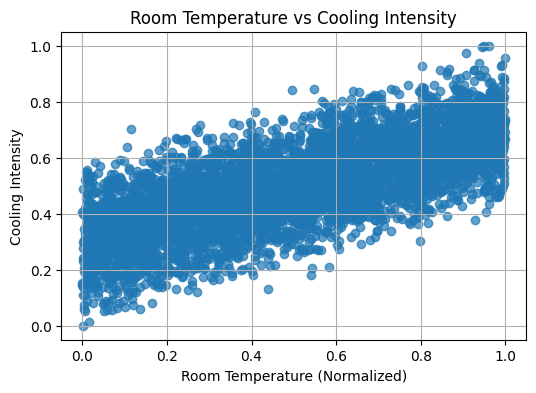

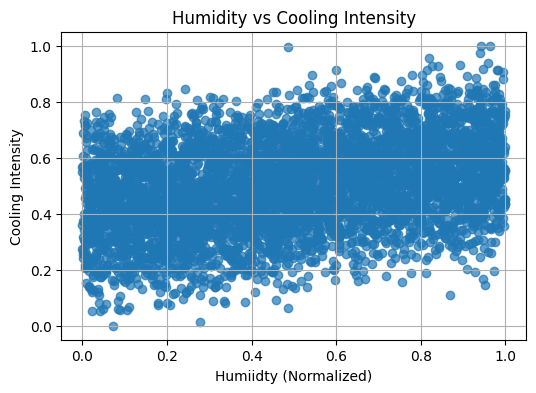

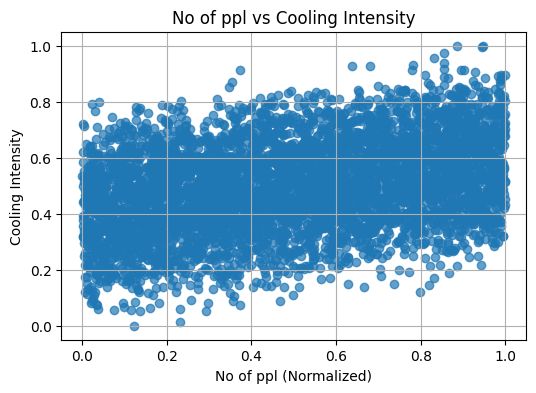

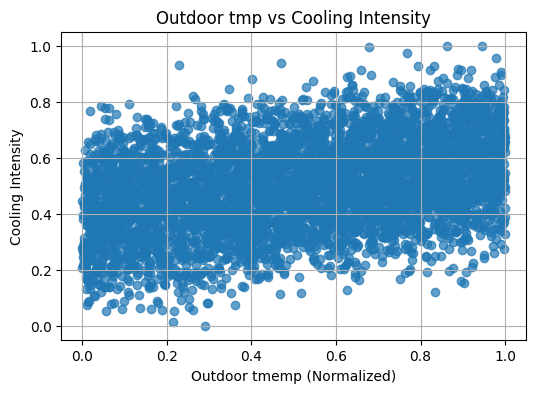

In [4]:
#Plotting Graphs


#graph1
# plt.figure(fig=(6,4))
plot.figure(figsize=(6,4))

plot.scatter(dataset['RoomTemp'],dataset['Cooling'],alpha=0.7)
plot.title("Room Temperature vs Cooling Intensity")
plot.xlabel("Room Temperature (Normalized)")
plot.ylabel("Cooling Intensity")
plot.grid(True)

plot.show()

#graph2
# plt.figure(fig=(6,4))
plot.figure(figsize=(6,4))

plot.scatter(dataset['Humidity'],dataset['Cooling'],alpha=0.7)
plot.title("Humidity vs Cooling Intensity")
plot.xlabel("Humiidty (Normalized)")
plot.ylabel("Cooling Intensity")
plot.grid(True)

plot.show()

##graph 3

# plt.figure(fig=(6,4))
plot.figure(figsize=(6,4))

plot.scatter(dataset['Occupants'],dataset['Cooling'],alpha=0.7)
plot.title("No of ppl vs Cooling Intensity")
plot.xlabel("No of ppl (Normalized)")
plot.ylabel("Cooling Intensity")
plot.grid(True)

plot.show()



##graph4
# plt.figure(fig=(6,4))
plot.figure(figsize=(6,4))

plot.scatter(dataset['OutdoorTemp'],dataset['Cooling'],alpha=0.7)
plot.title("Outdoor tmp vs Cooling Intensity")
plot.xlabel("Outdoor tmemp (Normalized)")
plot.ylabel("Cooling Intensity")
plot.grid(True)

plot.show()

In [5]:
#Converting data into tensors

X = dataset[
    ['RoomTemp','Humidity','Occupants','OutdoorTemp']
].values


##Output

y = dataset['Cooling'].values ## cooloong is a single value

# Remeber that we are working on simple 1d array i woudl need to convert it into 2d tensors since torch works in 2d arrya instead of 1d
# the constraints room temp , humiidty,occupants and outdoor temp was converted to features which will be feeded into model
tensor_X = torch.tensor(X,dtype=torch.float32)
tensor_Y = torch.tensor(y,dtype=torch.float32).view(-1,1) ## transpose

print("X shape:", tensor_X.shape)
print("y shape:", tensor_Y.shape)



X shape: torch.Size([5000, 4])
y shape: torch.Size([5000, 1])


### Now i am making a neural network which defined like this

$y = f(x_1, x_2, x_3, x_4)$

this will take 4 parameters (i alr told that above!!)

$x1$,$x2$,$x3$,$x4$ these are the enviroment constraints (inputs)

$x5$ is the output.

The neural network is broken down in layers in my case input and 3 hidden layers and one output

l1 -> first layer (input)
l2 -> Hidden layers
l3 -> output layer

Every neuron in one layer is connected to every neuron on next layer
each neuron is defined as:

$$
y = \mathbf{W}\mathbf{x} + \mathbf{b}
$$


Functions that i will use:

1) ReLU (Rectified Linear Unit)

It is defined as:

$$
f(max) = max(0,x)
$$

if input > 0 then keep it other wise make it 0 , its only for fast learning and learn patterns inside model

2) Sigmoid function (used on output)

it is defined as:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

It converts output to range from 0 to 1 so that output is smooth curve
In my assignemnt i made intensity from 0 to 1 (including datasets too)

So it will ensure that there are no -ve values and no value more than 1







In [6]:
#Building a NN

class ccNN(neural.Module):
    def __init__(self):
        super(ccNN,self).__init__()

        #layuer 1 (input wala)
        self.l1 = neural.Linear(4,16) # tkae 4 inputs and produce 16 featues (out from one neuron)

        #layer 2  (hidden)
        self.l2= neural.Linear(16,8)

        #Lyaer 3 (Output)
        self.l3 = neural.Linear(8,1)

        #setting up activation funciton
    
        ##RELU
        self.relu = neural.ReLU()
        ##Sigmoid
        self.sigma = neural.Sigmoid()     
    def forward(self,x) :
     x = self.relu(self.l1(x))
     x = self.relu(self.l2(x))
     x = self.sigma(self.l3(x))
     return x

mymodel = ccNN()
print(mymodel)


ccNN(
  (l1): Linear(in_features=4, out_features=16, bias=True)
  (l2): Linear(in_features=16, out_features=8, bias=True)
  (l3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigma): Sigmoid()
)


#### After then i will make loss function which tells how much wrong is prediction (by comparing predicted and acutal cooling)

It is defined as:

$$
Loss = \frac{1}{n} \sum (\hat{y} - y)^2
$$

$\hat{y}$ is the predicted cooling

$y$ is the acutual cooling

diffeence is the error

The errors are square so that negative dont cancel out positive ones and big errors are handled agressively

In [7]:
##Creating loss and optimizer

#loss

loss_calc= neural.MSELoss() #mean square error

optimizer = optim.Adam(mymodel.parameters(),lr=0.001)

## Training the Model

Make prediction (go random!!) -->   check error using loss functions --> fix it self (using back prop) --> repeat

<div style="text-align:center; font-family:Arial; background:#0f172a; color:white; padding:20px; border-radius:12px">

<div style="padding:10px; margin:10px; background:#1e293b; border-radius:10px; animation:fade 1s ease-in-out;">
🎲 Make Prediction (go random!!)
</div>

<div style="font-size:20px; color:#22d3ee;">⬇</div>

<div style="padding:10px; margin:10px; background:#1e293b; border-radius:10px; animation:fade 2s ease-in-out;">
📉 Check Error using Loss Functions
</div>

<div style="font-size:20px; color:#22d3ee;">⬇</div>

<div style="padding:10px; margin:10px; background:#1e293b; border-radius:10px; animation:fade 3s ease-in-out;">
🔁 Fix itself (using Backpropagation)
</div>

<div style="font-size:20px; color:#22d3ee;">⬇</div>

<div style="padding:10px; margin:10px; background:#1e293b; border-radius:10px; animation:fade 4s ease-in-out;">
🔄 Repeat
</div>

<!-- <div style="margin-top:15px; color:#38bdf8; font-weight:bold; animation:glow 2s infinite;">
⚡ Learning Loop Running...
</div> -->

<style>
@keyframes fade {
    from {opacity:0; transform:translateY(20px);}
    to {opacity:1; transform:translateY(0);}
}

@keyframes glow {
    0%,100% {text-shadow:0 0 5px #38bdf8;}
    50% {text-shadow:0 0 20px #38bdf8;}
}
</style>

</div>



I will be feeding dataset to model (training) in epochs(its an iteration)
and for each epoch pushing the loss value into array

The loss function will calcualte the loss.
and then i will use optimzimer to update the weights and the back propogation.
Pytorch handles propogation using gradient deviation

I will use gradient descent for this

after each back propogation the weight is is updated




In [8]:
epochs = 500

loss_history = []

for epoch in range(epochs):
    #forward pass
    y_pred = mymodel(tensor_X)

    #loss calculate
    loss = loss_calc(y_pred,tensor_Y)

    #backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/800 | Loss: {loss.item():.4f}")

Epoch 10/800 | Loss: 0.0328
Epoch 20/800 | Loss: 0.0303
Epoch 30/800 | Loss: 0.0279
Epoch 40/800 | Loss: 0.0259
Epoch 50/800 | Loss: 0.0242
Epoch 60/800 | Loss: 0.0226
Epoch 70/800 | Loss: 0.0213
Epoch 80/800 | Loss: 0.0201
Epoch 90/800 | Loss: 0.0190
Epoch 100/800 | Loss: 0.0180
Epoch 110/800 | Loss: 0.0169
Epoch 120/800 | Loss: 0.0158
Epoch 130/800 | Loss: 0.0146
Epoch 140/800 | Loss: 0.0132
Epoch 150/800 | Loss: 0.0119
Epoch 160/800 | Loss: 0.0106
Epoch 170/800 | Loss: 0.0093
Epoch 180/800 | Loss: 0.0082
Epoch 190/800 | Loss: 0.0071
Epoch 200/800 | Loss: 0.0062
Epoch 210/800 | Loss: 0.0055
Epoch 220/800 | Loss: 0.0048
Epoch 230/800 | Loss: 0.0043
Epoch 240/800 | Loss: 0.0039
Epoch 250/800 | Loss: 0.0036
Epoch 260/800 | Loss: 0.0033
Epoch 270/800 | Loss: 0.0032
Epoch 280/800 | Loss: 0.0030
Epoch 290/800 | Loss: 0.0029
Epoch 300/800 | Loss: 0.0029
Epoch 310/800 | Loss: 0.0028
Epoch 320/800 | Loss: 0.0028
Epoch 330/800 | Loss: 0.0027
Epoch 340/800 | Loss: 0.0027
Epoch 350/800 | Loss: 0

<function matplotlib.pyplot.show(close=None, block=None)>

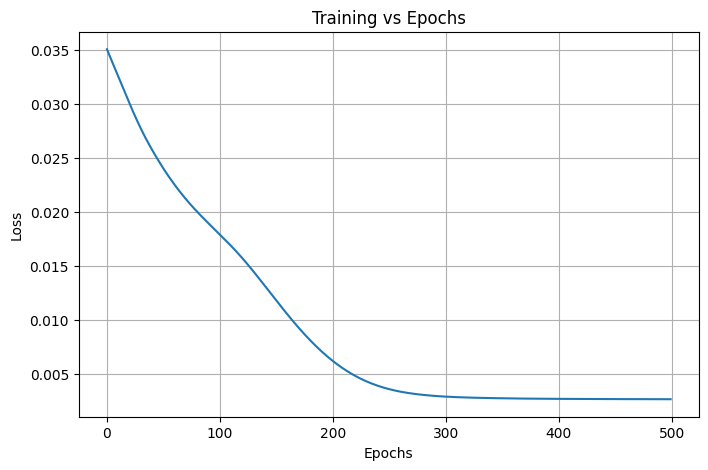

In [9]:
##graph for loss

plot.figure(figsize=(8,5))
plot.plot(loss_history)
plot.title("Training vs Epochs")
plot.xlabel("Epochs")
plot.ylabel("Loss")
plot.grid(True)
plot.show

As you can see the above graph the it reaches constant at 0.005 loss

it means that
 $$
\frac{d\,Loss}{dt} \to 0
$$

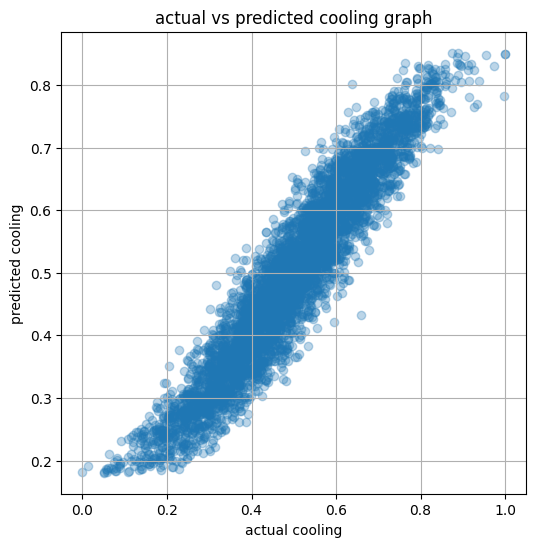

In [10]:
#now plotting graph for prediction vs actual

with torch.no_grad(): 
    y_pred = mymodel(tensor_X)

y_pred = y_pred.numpy()
y_true = tensor_Y.numpy()


plot.figure(figsize=(6,6))
plot.scatter(y_true,y_pred,alpha=0.3)
plot.xlabel('actual cooling')
plot.ylabel('predicted cooling')
plot.title('actual vs predicted cooling graph')
plot.grid(True)
plot.show()

In [11]:
## now test model by giving values (user gives)
# Written by ChatGPT cuz i was lazy

def get_valid_input(prompt):
    while True:
        try:
            value = float(input(prompt))
            
            # validation: range check
            if 0 <= value <= 1:
                return value
            else:
                print("❌ Value must be between 0 and 1. Try again.\n")
        
        except ValueError:
            print("❌ Invalid input. Please enter a numeric value.\n")


def predict_cooling(model):
    print("\n=== Smart Climate Control Prediction ===")
    print("Enter all values between 0 and 1\n")
    
    # validated inputs
    x1 = get_valid_input("Room Temperature (0–1): ")
    x2 = get_valid_input("Humidity (0–1): ")
    x3 = get_valid_input("Occupants (0–1): ")
    x4 = get_valid_input("Outdoor Temperature (0–1): ")
    
    # convert to tensor
    user_input = torch.tensor([[x1, x2, x3, x4]], dtype=torch.float32)
    
    # prediction
    with torch.no_grad():
        prediction = model(user_input)
    
    result = prediction.item()
    
    # classification for better UX
    if result < 0.3:
        level = "Low Cooling ❄️"
    elif result < 0.7:
        level = "Moderate Cooling 🌡️"
    else:
        level = "High Cooling 🔥"
    
    print("\n✅ Predicted Cooling Intensity:", round(result, 4))
    print("📊 Cooling Level:", level)

In [ ]:
predict_cooling(mymodel)


=== Smart Climate Control Prediction ===
Enter all values between 0 and 1

